## The First Formal Tool: Univariate Analysis
#### Univariate means one variable. Univariate analysis means we will only analyse one variable
#### This approach may be too simple for realistic analysis, but in practice, it's actually quite effective. 
#### In many cases, we can narrow down our analysis to one single important input by assuming that any other variables are independent, meaning that values outside variable affects the value of a given data point. This is assumption that is almost never true, but it often works out well enough in practice that we can perform a reasonable statistical analysis regardless.

### Distributions and Histograms
#### When looking at one-dimensional data, our focus is on the distribution of that data. A simple way to think of a distribution is the shape of the data. That is, how often do we see any particular value in the dataset?
- #### A discrete variable has a finite and known number of possible values. By contrast, a continuous variable has an infinite number of possible values. When building a histogram from a continuous variable, we typically dont care as much about the exact value of the variable but can make do instead with an approximation, allowing us to aggregate the values within a certain range and display them as a single group, which we call a bin
- #### There is no single "correct" number of buckets across all datasets. We typically use histograms to help understand the shape of the data, and so the "correct" number of bins is one that gives us information about the shape of the distribution without an excess of noise

    ### Log-Normal Distribution
#### The normal distribution shows up fairly frequently in our lives, but many important things are not normally distributed. For example, if you look at the population of towns in a given state, dollar amounts in line items for budgets, these datasets do not follow a normal distribution. Instead, they follow a log normal distribution, which means that the logarithm of values will follow a normal distribution, not the values themselves. The normal distribution follows a symmetric "bell curve" shape, but the log-normal distribution has a "long tail", meaning that u are more likely to see a value on the left hand side of the peak than on the right hand side. One important note about log normal distribution is that because this is a logarithmic calculation, all values in the collection must be greater than zero as u cannot take the logarithm of a negative number or zero.

### Mean and Robustness
#### Robustness is defined as protecting against a certain number of outliers. For example, we can say that the median is  more robust than mean, which means that the median is less likely affected by outliers than the mean. We can say that the median is a robust statistic. MAD is another robust statistic, one that acts as a replacement for standard deviation. The formula is:
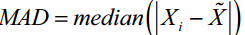
#### That is, we take the median of the absolute value of differences between individual values and the median of our set. Because our median is 8.75, we subtract 8.75 from each of the collection items and take its absolute value, leaving us with { 1.45, 0.55, 0.35, 0.35, 0.55, 0.85 }. The median of this collection is 0.55.

### Control Charts
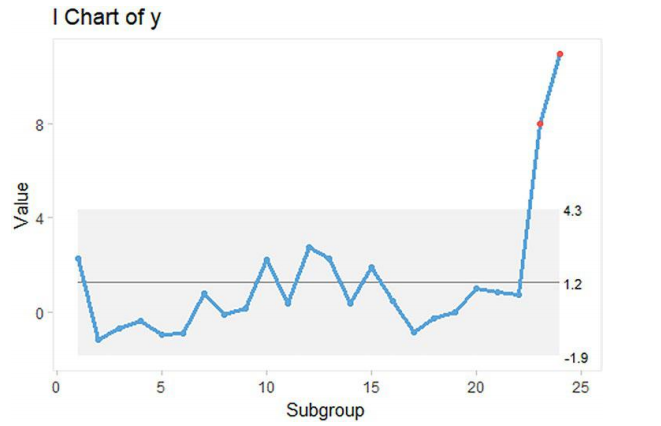

# Laying Out the Framework 
## Making Plumbing Choices 
#### We should make a few decisions about how our end users will interact with the service. The first question we should ask is, why do our customers need this service? The more we understand what kinds of problems they want to solve, the better we can tailor our service to fit their needs. For our scenario, let's suppose that our end users wish to call our service and get a response back in near real time, rather than sending in large datasets and requesting batch operations over the entire dataset. The techniques we will use throughout the book will work just as well for both situations, but how we expose our service to the outside world will differ dramatically as a result of this decision
#### Given that we wish to allow end users to interact in a real-time scenario, we will likely wish to use HyperText Transfer Protocol as our transfer mechanism of choice. We could alternatively design our own solution using Transimission Control Protocol (TCP) sockets, but this would add a significant amount of development overhead to creating a solution and would require that our users develop custom clients to interact with our service.
#### Sticking with HTTP as our protocol of choice, we now have two primary options for how we create services, both of which have a significant amount of support in Python: the Remote Procedure Call framework gRPC or building a Representational State Transfer (REST) API using JavaScript Object Notation (JSON) to pass data back and forth between our service and the client. 
- #### The gRPC-based solution has some significant advantages, starting with payload size. Payloads in gRPC are in the Protocol Buffer (Protobuf) format, a binary format that compacts down request sizes pretty well
- #### By contrast, JSON is a relatively large, uncompressed text format. JSON is more compact than other formats like Extensible Markup Language (XML), but there can be a significant difference in payload size between Protobuf and JSON, especially in batch processing scenarios. 
- #### We also have strict contracts when working with gRPC, meaning that clients know exactly what the server will provide, what parameters and meaning that clients know exactly what the server will provide, what parameters and flags exist, and how to form requests. 
- #### For the purpose of this book, we will choose to work with a REST API using JSON. There are three reasons for this choice. First, working with REST allows us to use freely available tools to interact with our service, including web browsers. The gRPC framework has very limited support for browser-based interaction, whereas REST works natively with browsers. The second reason for choosing REST over gRPC is that a REST API with JSON support provides us human-readable requests, making it easier for humans to parse and interpret requests and correct potential bugs in the client or the service. The final reason we will use REST APIs over gRPC is that more developers are familiar with the former than the latter. 
## Reducing Architectural Variables
- #### There are several Python-based frameworks to make API development easy, including Flask and FastAPI. Flask is a venerable package for core API development and integrates well with proxy solutions like Gunicorn. FastAPI, meanwhile, is a newer solution that has a lot going for it, including great performance and automatic implementation of the OpenAPI specification using a tool called ReDoc.
- #### Beyond this, we can also use Docker containers to deploy the application. That way, no matter which operating system u are running or what libraries you have installed, you can easily deploy the end solution. Using the container version of the solution we build is optional, but if u do have Docker installed and want to simplify the dependency management process,u can use it


## Developing an initial framework
### Battlespace Preparation 
#### The repository includes several folders. The \doc\ folder includes basic documentation about the project, including how to run different parts of the project. The \src\app\ folder includes the completed version of the code base we will work throughout the book to create. The \src\comp\ folder includes comparison work we will cover in the final chapter of this book. The \src\web\ folder includes a companion website we will create and update throughout the book. Leaving the \src\ directory altogether, the \test\ folder features two separate sets of tests: one set of unit tests and one set of integration tests. Finally, we have a Dockerfile for people who wish to run the solution as a Docker container, as well as a requirements.txt file.

### Framing the API 
- #### __init__.py, will let the python interpreter know that our app folder contains code for a Python module.
- #### main.py will be the entry point for our API 
- three good options for the editor of choice are VSC, Wing IDE and PyCharm, spyder 
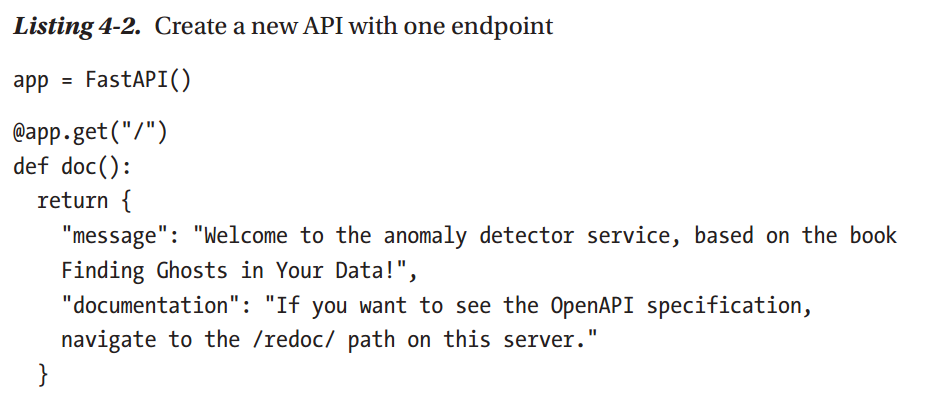

- In this block of code, we first create a new API service called app. We then create a new endpoint for our application at the root directory. This endpoint accepts the GET method in REST. The GET method does not take a request body, and it is expected to return something. When navigating to web pages or clicking links using a browser, the browser translates these statements to GET operations.
- After defining the endpoint, we now need to write out what our code should do if someone were to call that endpoint. In this case, we return a message. The message must be a valid JSON. In this case, we create a JSON object with two attributes: message and documentation. 
Now, that we have a functional API service, the next step is to lay out the input and output signatures we will need throughout the book 
### Input and Output Signatures
- #### Each API endpoint will need its own specific input and output structure. 
- #### Stub methods allow us to define the structure of the API without commiting to all of the implementation details. They will also allow us to tackle one problem at a time during development while still making clear progress. 

### Sensitivity and Fraction of Anomalies
- Sensitivity: We do not mean sensitivity as a technical definition but rather a sliding scale. Ideally, callers will be able to control - without knowing exact details about thresholds - the likelihood that our outlier detector will flag st as an outlier. We will have the sensitivity score range from 1 to 100 inclusive, where 1 is least sensitive and 100 is most sensitive. How, exactly, we implement this will depend on the technique, but this gives callers a simple mechanism for the purpose
- Maximum fraction of anomalies we would expect to see in the dataset : Some outlier detection techniques expect an input that includes the maximum number of items that could be anomalous. Rather than trying to estimate this for our users, we can ask directly for this answer. This will range from 0.0 to 1.0 inclusive, where 1.0 means that every data point could potentially be an outlier. In practice, we would expect values ranging between 0.05 and 0.1, meaning no more than 5-10% of records are outliers. This fraction can also give us a hard limit on how many items we mark as outliers, meaning that if a caller sends in 100 data points and a max fraction of anomalies of 0.1, we guarantee we will return no more than ten outliers. This will work in conjunction with the sensitivity score: think of sensitivity score as a sliding scale and max fraction of anomalies as a hard cap
### Single Solution
- If, for a given class of problem, there is a single best technique to solve the problem, we can use this technique to the exclusion of any other possible techniques. In that case, calculations are fairly straightforward: we apply the input data to the given algorithm, sending in the sensitivity score and max fraction of anomailies inputs if the technique calls for either or both. We get back the number of outlier items and then need to determine whether we can simply send back this result set or if we need to perform additional work. For cases in which the input technique accepts sensitivity score or max fraction of anomalies, our work is probably complete by then , otherwise, we will need to develop a way to apply the sensitivity score and then cut off any items beyong the max ffraction of anomalies. This works because each technique will apply a score to each data point and we can order these scores in such a way that higher scores are more likely to be outliers, With these scores, even if the technique we use has no concept of sensitivity or a cutoff point, we can implement that ourselves
### Combined Arms
- The more difficult scenario is when we need to create ensemble models, that is, models with several input algorithms. Here, we will need a bit more control over which items get marked as outliers, as each technique in the ensemble will have its own opinion of the outlier-worthiness of a given data point. We will need to agglomerate the results and perform the final scoring and cutoffs ourselves.
- We will also want to provide weights for each input algorithm. Some techniques are more adept at finding outliers than others, and so we will want to weigh them more heavily. But there is a lot of value in incorporating a variety of input strategies, as no single technique is going to be perfect at finding all anomalies and ignoring all noise. For this reason, even relatively noisier techniques can still provide value, especially when there are several of them. Our hope is that the noise “cancels out” between the techniques, leaving us with more anomalies and (ideally!) less noise.
- In the simplest case, we can weight each of the techniques equally, which is the same as saying that we let each technique vote once and count the number of votes to determine whether a particular data point is an outlier or not. With larger numbers of techniques, this may itself be a valid criterion for sensitivity score—suppose we have 20 separate tests. We could give each test a weight score of 5, giving us 5 * 20 = 100 as our highest score. This aligns quite nicely with sensitivity score, so if the caller sends in a sensitivity score of 75, that means a particular data point must be an outlier for at least 15 of the 20 tests in order to appear on our final list - With differential weighting, the math is fundamentally the same, but it does get a
little more complicated. Instead of assigning 5 points per triggered test, we might assignsome tests at a value of 10 and others 2 based on perceived accuracy. The end resultis that we still expect the total score to add up to 100, as that lets us keep the score in alignment with our sensitivity score.
- Regardless of how we weight the techniques, we will want to send back information on how we perform this weighting. That way, we will be able to debug techniques and get a better feeling for whether our sensitivity score is working as expected
## Framing the Solution
- As far as inputs go, we will need to define input_data as the correct kind of list. FastAPI includes a concept called BaseModel that allows us easily to interpret the JSON our caller passes in and convert it into an object that Python understands. For univariate statistical input, we will need a single value column. It also would be proper to add a key column as well. That way, if the caller wishes to assign specific meaning to a particular value, they can use the key column to do so. We will not use the key as part of data analysis but will retain and return it to the user
- The detect_univariate_statistical() function should take in the sensitivity score and max fraction of anomalies and output the weights assigned for particular models, as well as any other details that might make sense to include for debugging.
- For multivariate outlier detection, we will replace the single float called value with a list of values. Single-input time series anomaly detection will bring back the singular value but will include a dt parameter for the date and time. Finally, multi-series time series anomaly detection will add the date and also a series_key value, which represents the specific time series to which a given data point belongs. 
### Containerizing the Solution
We have a solution and we can run it as is on our local machines, but suppose we wish to deploy this solution out to a service like Azure Application Services. How would we package up this code and make it available to run? One of the easiest ways of packaging up a solution is to containerize it. The big idea behind containers is that we wish to pull together code and any project dependencies into one single image. This image can then be deployed as an independent container anywhere that runs the appropriate software. I can package up the software from this API and make the image available to you. Then, you can take that image and deploy it in your own environment without needing to install anything else.
- Docker is one solution to containerizing
  - Docker desktop is free for personal use
  - Lima works for MAC

# Building a Test Suite

## Tools of the trade
- Unit tests: is to exercise some narrow capability of an application's code. Generally, we create unit tests against individual functions or methods in the code base, exercising that function with a variety of normal, abnormal, and even outlandish inputs to ensure that the code behaves appropriately in all of these circumstances
- Integration test: to exercise the combination of code components. Our unit tests determine if a given function works as expected given some set of inputs, and our integration tests ensure that the broader application behaves as expected. Because our outlier detection application runs on FastAPI, the most obvious integration testing process would drive from those API calls, as they represent the way that end users will operate our system
## Unit test library
pytest 
## Integration testing 
postman: It is easy to create one-off tests in Postman, but you can also create collections of tests and run them from the Postman application, through the postman service 
## keep methods separated
- First we want to limit the size and scope of python methods and functions. A good idea is to have a python method do one thing very well. It may not always be possible to limit a method to one thing, but as a rule of thumb, break out as much as u can. 
- The obvious benefit is that we can test methods independent of one another, making it easier to isolate and test functionality. The less obvious benefit is that by breaking code out into component methods, we have the opportunity to test not only the specific use cases our current code covers but other logical use cases as well
## Emphasize use cases
- Following on from the first point, our code should work to implement specific business use cases, in which actors—that is, people or systems that interact with our application— have needs or desires and it is our application’s job to fulfill those desires. For example, in our outlier detection algorithm, an end user wants to determine which points in a set of time series data points are anomalous. These specific use cases may require quite a few functions to get the job done, but we want to keep the use case in mind and develop tests that ensure that we can satisfy the use case. These tests will typically be integration tests rather than unit tests, as we want to ensure that the behavior of the application is such that we satisfy the actor’s desires.
## Functional or Clean
-  We can write high-­ quality, testable Python code in two different ways, taking either a functional approach or an object-oriented approach.
- The functional approach emphasizes small, deterministic functions, By deterministic, i mean functions that, given a particular set of inputs, always return the same outputs. As an example, translating temperatures from Celsius to Fahrenheit is a deterministic operation. No matter, how many times we call the conversion function, it should always return the same value. As a counterexample, getting the logged-in user's remaining loan amount will be nondeterministic in nature.
- Another important aspect of functional programming relevant to writing testable python code is that functions should not have side effects. In other words, functions take inputs and convert them to outputs; they don't do anything else.
## Unit Tests
- Inside the file, pytest will only consider a method to be a test if it starts with 'test' or is in a class whose name starts with "Test". 
- after defining the test method, we have three sections: arrange, act and assert
  - arrange: we perform all of the necessary setup
  - act: call the method under test. We pass in the inputs and expect to get back a tuple of outputs
  - assert: perform the actual testing using a series of assertion statements
One test is great, but we will often wish to test several different sets of input parameters. For example, our test works great with a set of ten elements, but how would it work against other DataFrames? Will it work just as well if we have a single element in our DataFrame? What about an empty DataFrame? We could create separate tests for each of these, but it would involve quite a bit of copy and paste, and frankly, our test names are long enough as it is! Fortunately for us, pytest includes the ability to run the same test with multiple sets of inputs. This allows us to try a variety of situations, including normal inputs, edge cases, and situations that previously caused bugs in the code. In Listing 5-2, we use the @pytest.mark.parameterize() indicator to try out several possible tests. Note that for this to work, we also need to add a new input parameter for the test method: our input list for the Pandas DataFrame.
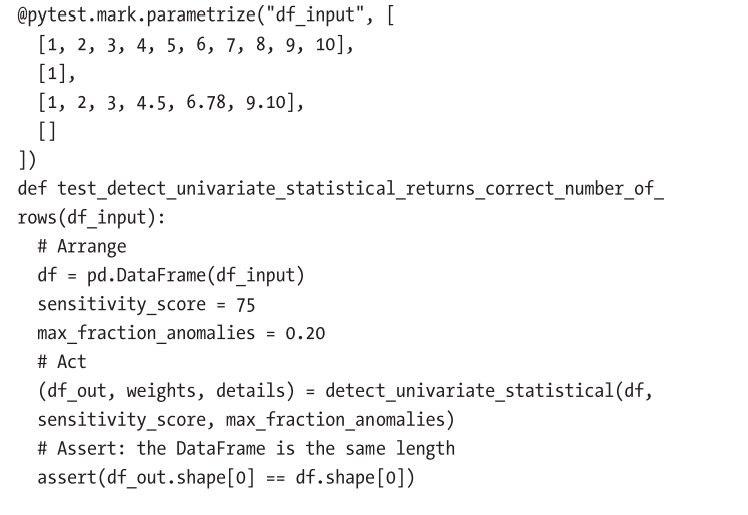

# Implementing the Methods 
## A Motivating Example: 
- A univariate outlier detector sounds rather limiting: almost no phenomenon is so simple that we can boil it down to a single variable. In practice, though, univariate anomaly detection can be extremely powerful, as our purpose is not to explain the world but rather to understand if something strange has happened. 
- For example, your PC is a complicated mixture of parts, and it would be folly to believe that any single measure could completely describe the health of your machine. There are, however, single measures that can describe the health of some part of your PC. For example, CPU temperature is a great measure of how well your computer’s cooling systems are working, and there are optimal ranges based on ambient temperature and workload. A quick rule of thumb is that under heavy load, a modern CPU will typically run anywhere from 60 to 80 degrees Celsius (140–176 degrees Fahrenheit), but temperatures above this can be dangerous. If we track the output of a CPU’s thermal sensor by collecting the average temperature over common intervals (e.g., ten-second or one-minute intervals), we could use univariate statistical analysis to check if there are temperatures well above the norm. These high temperatures could indicate a problem with some aspect of our cooling solution, extreme load on the system, or a problem with the thermal sensor. The goal here is not to determine the cause but to provide information to an operator that something deserves the operator's attention.
## Ensembling as a technique
- The tests we will use in this chapter are all fairly simple statistical tests. The major benefit to these tests being simple is that they are also quite fast. The major drawback to these tests being simple is that we do not have much opportunity to tune these tests and make them less noisy. This is where a technique known as ensembling can be quite beneficial to us.
### Sequential Ensembling
- The idea behind sequential ensembling is that we run each test in turn and the results from the prior test feed the subsequent test,
- Generally, sequential ensembling works by narrowing down the relevant set of potentially controversial data points. If the first model is extremely confident in a prediction, we might not want subsequent models to waste time on those data points. Instead, subsequent models try to answer the questions the first model found difficult. For this reason, we usually want the best model to go first and take care of as many data points as it can.
- When using sequential ensembling, there is no guarantee that we will find a model that is supremely confident for any given data point. Thus, by the end, we might have some data points none of the models conclusively define as either an outlier or inlier. In that case, we could report back the results from the final test in the ensemble. Alternatively, we might break down to simple voting: with five tests, if three report that a data point is an outlier and two do not, we call it an outlier
### Independent Ensembling
- Sequential ensembling can be great, but it does come with a risk: What if a model is confidently wrong? If our first model is very confident in a result but it turns out to be the wrong guess, none of the subsequent models will test it out and find this discrepancy. This is where independent ensembling comes into play. With independent ensembling, we still have a battery of tests that we perform on a dataset. The primary difference, however, is that these tests are done independently of one another—that is, the results of Test A are not fed into Test B, Test C, or any other test. Instead, each test is run over the entirety of the input data and generates predictions for every data point. Once we have all of the tests computed for all of the data points, we then need to combine together the results.
- The simplest technique for combining together results is to count the number of times a test calls a given data point an outlier and see if we meet a certain threshold. Suppose we have five tests and require a simple majority to decide to label a given point an outlier. In that case, we would need three of the five tests to agree before we make the call, regardless of how confident any given test is in its prediction. Another technique we can use is to weight the individual tests. For example, suppose that Test A tends to be fairly accurate and Test B is a bit less accurate on the whole but neither test is sufficiently accurate to stand on its own. In this case, we might give Test A more voting shares than Test B, such that if there is disagreement, Test A will override Test B.
## Choosing between Sequential and Independent Ensembling
- First, if you have one particularly good algorithm, sequential ensembling can be superior to independent ensembling. This would allow us to rule out a large number of data points after the first test, making subsequent tests significantly faster. By contrast, independent ensembling would require that we run all data points against all tests, meaning that performance (in terms of speed) will not be as good.
- By contrast, if you have a series of similar-quality algorithms but nothing that dominates, the independent ensembling technique is the safer approach. This will reduce the likelihood of incorrectly labeling an outlier as an inlier (or vice versa), and that can make up for independent ensemble being slower to run.
- Second, if you know the performance characteristics of specific algorithms, a sequential ensembling process can make more sense. For example, under specific conditions, one algorithm might be more sensitive to outliers than another, but suppose that it works better on small numbers of rows than large numbers. In that case, you could try to gauge some of the characteristics of your dataset, determine if it more closely fits the first or the second algorithm, and lead with that one, using the other to act as a cleanup test. If you do not know exactly when one algorithm beats another, the independent ensemble is a safer choice. Finally, if you have complementary checks, sequential ensembling will typically be better—that is, if there is relatively little overlap in the failure zones of each algorithm, feeding results sequentially and paring down the datasets will typically work well.

## Implementing the first checks
standard deviations from the mean,distance from the interquartile range, and median absolute deviations from the median.
- Reviewing our checklist from before, we do not have one algorithm that is head and shoulders above the rest. Median absolute deviations from the median is a more robust version of standard deviations from the mean, so the former will be better. That said, both will catch a lot, and there may be cases in which we want the added information from our test of standard deviations from the mean. Distance from the interquartile range covers a different space from our variance-based measures, but “different” is not guaranteed to be better here.

## Standard Deviations from the MEan
The first test we will implement checks whether a particular data point is more than a given number of standard deviations from the mean. We can call this function check_sd(), and it will run once for each data point in our dataset. The check_sd() function will take four parameters: the value (value), the mean of the dataset (mean), the standard deviation of the dataset (sd), and the minimum number of standard deviations’ difference before we report an outlier (min_num_sd).
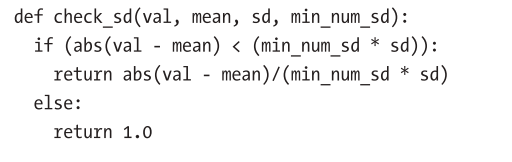
- This function checks to see if the absolute difference between our value and the mean is more than the minimum number of standard deviations. If the difference between our data point’s value and the mean is within the acceptable range, we return the percentage of the way to our threshold of min_num_sd standard deviations. If the difference is outside of the acceptable range, we return a score of 1.0, indicating that this test considers the data point an outlier.
- When we call check_sd(), we will know the data point’s value, as the caller sends us this information. We will also know the minimum number of standard deviations, as we set this to 3. We will need to calculate the mean and standard deviation in the run_ tests() function, something that is easy to do with Pandas DataFrames: df['value']. mean() and df['value'].std(), respectively

## Median Absolute Deviations from the Median
The second test we will implement in this chapter checks whether a particular point is more than a given number of median absolute deviations from the median. This is a robust version of our check for standard deviations from the mean, which means that a few outliers will not substantively affect the quality of our test. Because the code for this test is fundamentally similar to the prior test, we should create a common function for midpoint-based statistical tests.
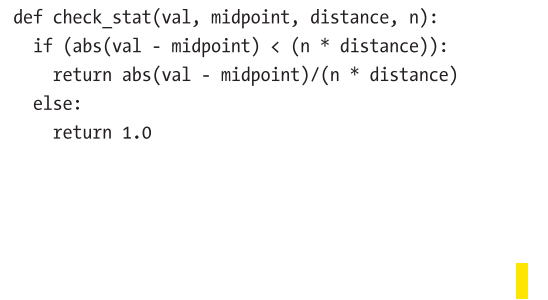

## Distance from the Interquartile Range
- As a reminder, the interquartile range is the difference between the 25th and 75th percentiles. As a reminder, the interquartile range is the difference between the 75th and 25th percentiles of a dataset. 
- We consider a value an outlier if one of two things is true: either it is more than 1.5 interquartile ranges above the 75th percentile or it is more than 1.5 interquartile ranges below the 25th percentile. The check_iqr() function will take six values: the value (value), the median of the dataset (median), the 25th percentile (p25), the 75th percentile (p75), the interquartile range of the dataset (iqr), and the minimum number of interquartile ranges from the relevant percentile before we report an outlier (min_iqr_ diff).
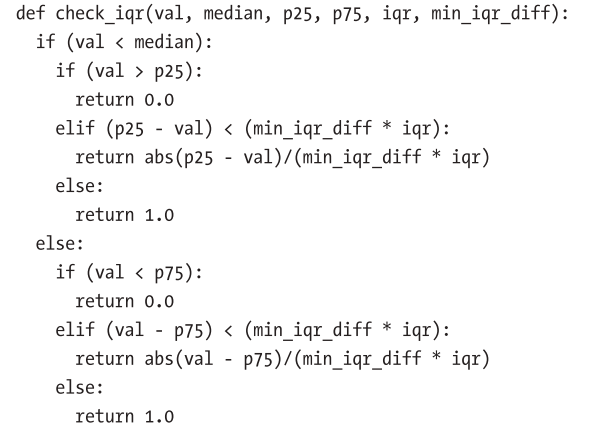
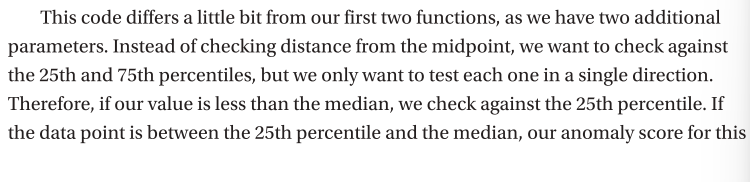
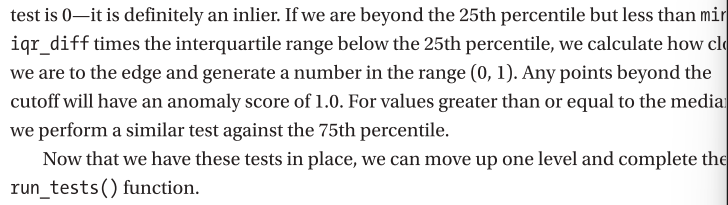

## Completing the run_tests() Function
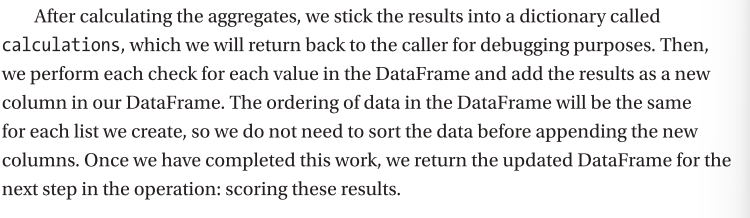

## Building a Score board
So far, we have a series of tests, each of which provides its own calculation of how anomalous a particular data point is. We now want to combine these independent tests and return back to the end user a unified anomaly score and classification of whether a given data point is anomalous. 
- When it comes to creating a scoring function, the check methods already give us a head start, as they provide two things. First, they give us a clear indicator of whether a test marks something as an outlier or an inlier. Secondly, if we do find a data point that lies outside these margins, we get a direct indicator that we consider something to be an outlier. 
- The benefit is that an extreme outlier will not obscure less-extreme outliers - something 50 interquartile ranges from the 75th percentile is still an obvious outlier, even if another data point is 500 interquartile ranges away. The downside risk here comes from the fact that our capping of what constitues an outlier might cause problems if the distribution of data is nothing like the normal distribution. In those cases, we might end up with too many outliers, leading to more noise

## Weighting Results
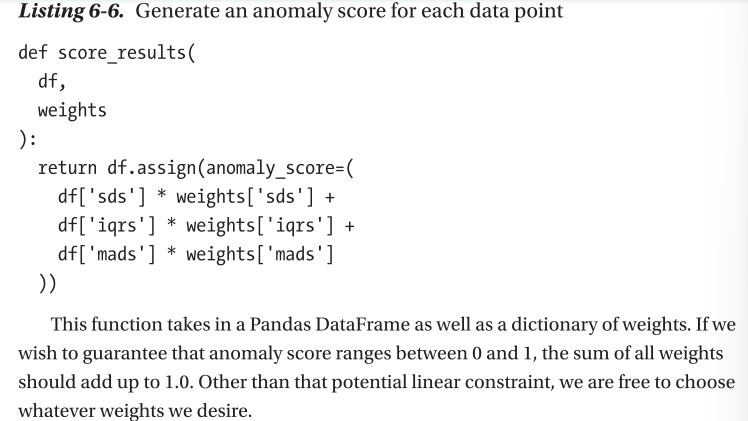
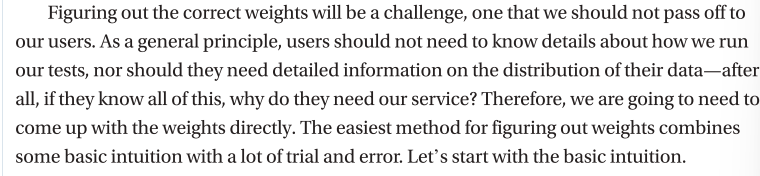
- when we have both robust and nonrobust statistics in our test set, we should bias toward the robust statistics, as they are more likely to remain sensitive in the face of some percentage of outliers. 
- Comming up with exact numbers for these weights would require running statistical test against a variety of relevant datasets for your particular environment and trying to ascertain which weights do the best job of finding outliers without being wrong too often. The bggest challenge is that we typically do not have labeled data that indicates when there really was an anomaly; without that critical pieces of information, we can track outliers but may not b able to guarantee that any given set of weights will be optimal for some environment
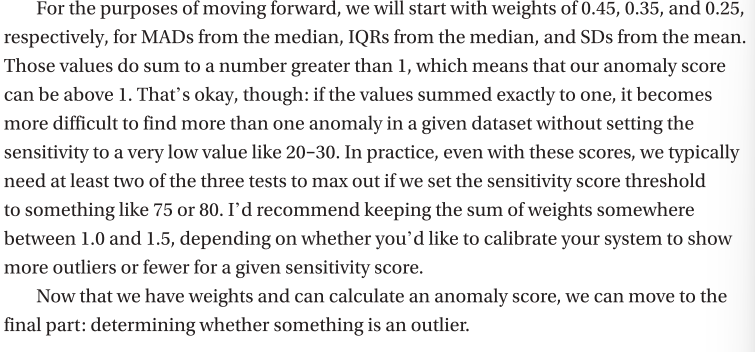

## Determining Outliers
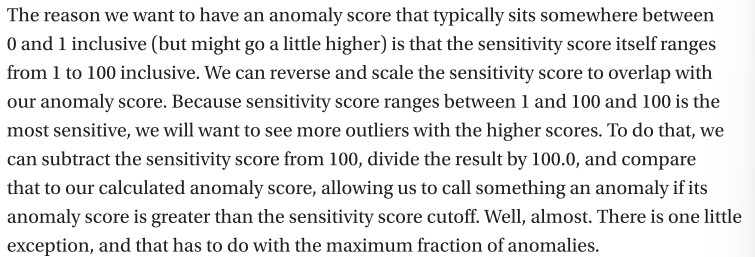
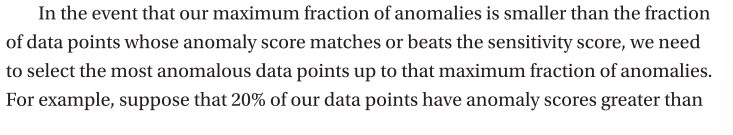
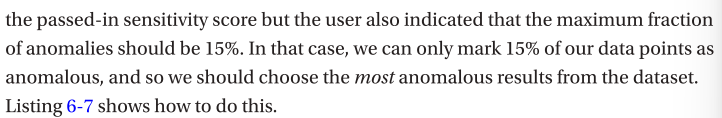
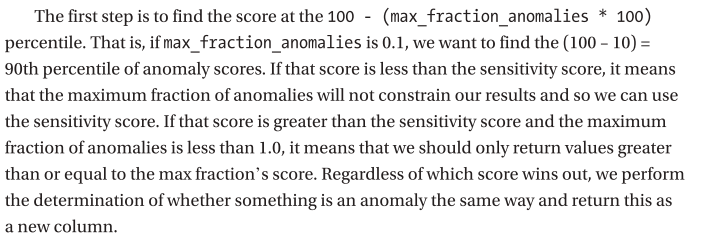

# Chapter 7 Extending the Ensemble
## Adding New Tests
there are several tests we can perform if the data fits closely enough
to a normal distribution.
  - There are several tests that can inform us as to whether a particular dataset appears to follow a normal distribution. The first test we will look at is called the Shaporo-Wilk test
  - kurtosis of dataset indicates the amount of a distribution contained in the tails. The kurtosis of a normal distribution is 3, and as the kurtosis increases, the likelihood of seeing outlier data points increases
## Checking for anomality
The function begins by setting an alpha value of 0.05, following our general principle of not having users make choices that require detailed statistical knowledge. Then if the dataset has fewer than 5000 observations, we run the Shapiro-Wilk test, otherwise, we skip the test. If we have at least eight observations, we can run D'Agostino's K-squared test. Finally, no matter the sample size, we may run the Anderson-Darling test. 
- When it comes to making a determination based on these three tests, we have to make a decision, similar to how we weight our ensembles. We can perform simple voting or weigh some tests greater than others. In this case, we will stick with a simple unanimity rule: If all three tests agree that the dataset is normally distributed, then we will assume that it is; otherwise, we will assume that it is not normally distributed. 

## Approaching Normality
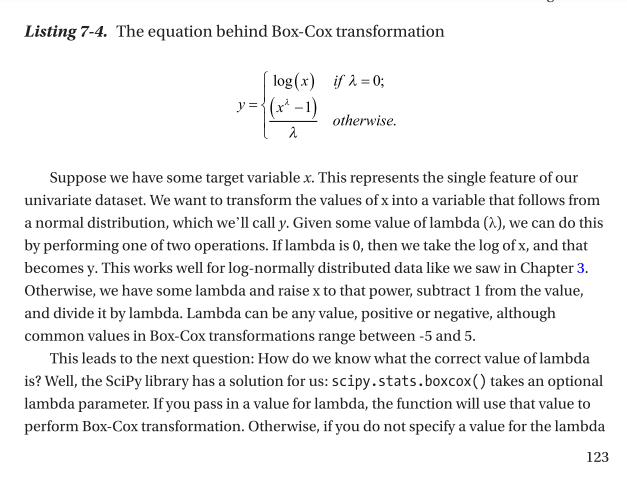
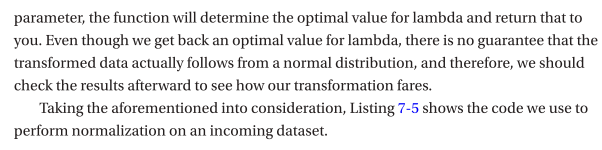
- The first thing we do is find the middle 80% of ur input data. The rationale behind this is that Box Cox transformation is quite effective at transforming data. So effective that it can smother outliers in the data and make the subsequent tests lose a lot of their value in identifying outlier values. Therefore, we will focus on the central 80% of data, which we typically do not expect to contain many outliers. Running boxcox() on the central 80% of data, we get back a fitted lambda value. We can then pass that value in as a parameter to perform the transformation against our entire dataset, returning the entirety of fitted data as well as the fitted lambda we built from the central 80%

## Grubbs' Test for outliers 
- The assumption with this test is that there are no outliers in the dataset, with the alternative being that there is exactly one outlier in the dataset. There is no capacity to detect more than one outlier
- Although this test is quite limited in the number of outliers it produces, it does a good job at finding the value with the largest spread from the mean and checking whether the value is far enough away to matter.
- We can run grubbs' test using the scikit_posthocs package in python. This third-party package includes several outlier detection checks. Calling the test is simple: ph.outliers_grubbs(col) is sufficient, where col is the column containing fitted values in our dataframe. The function call then returns the set of inliers, which means we need to find the difference between our initial dataset and the resulting inlier set to determine if there are any outliers
- The find_differences() function takes in two datasets: our fitted values(col) and the output from the call to Grubbs' test (out). We convert each of these to a set and then find the set difference- that is, any elements in the fitted values set that do no appear in the results set. Note that duplicate values are not allowed in a set and so all references to a particular outlier value will become outliers.For example, if we have a fitted values dataset of [0,1,1,2,3,9000,9000] the fitted values set becomes {0,1,2,3,9000}. If our output dataset is [0,1,1,2,3], we convert it to a set as well, making it {0,1,2,3}. The set difference between these two is {9000}, so every value of 9000 will become an outlier. We do this by creating a new result column that has as many data points as we have elements in the fitted values dataset. Then, for each value in the set difference, we find all references in the fitted values dataset matching that value and mark the matching value in our results dataset to 1.0 to indicate that the data point represents an outlier. We then return the results list to the caller. 

## Generalized ESD TEst for outliers
The generalized extreme Studenized deviate test, otherwise known as GESD or generalized ESD, is the general form of Grubbs' test. Whereas Grubbs' test requires that we have either no outliers or one outlier, generalized ESD only requires that we specify the upper bound of outliers. At this point, u may note that we already keep track of a max_fraction_anomalies user input, so we could multiply this fraction be the number of input items and use that to determine the maximum upper bound. This idea makes a lot of sense in principle, but it does not always work out in practice. The reason for this is a concept known as degrees of freedom. 

- Degrees of freedom is a concept in statistics that relates to how many independent values we have in our dataset and therefore how much flexibility we have in finding missing information (in our case, whether a particular data point is an outlier) by varying those values. If we have a dataset containing 100 data points and we estimate that we could have up to five outliers, that leaves us with 95 known inliers. ESD is built off of a distribution called the t (or student -t) distribution, whose calculation for degrees of freedom is the number of data points mi
